# Heart Disease Prediction by Dorota Perenc

The goal of this project is to predict whether a given patient is suffering from heart disease. I will be using a dataset containing various health metrics collected from cardiology patients (source: https://www.kaggle.com/code/farzadnekouei/heart-disease-prediction/input). I will be using several different algorithms for this purpose (KNN, logistic regression, decision trees, random forests, XGBoost, MLPs) and comparing their performance based on metrics such as accuracy, precision, recall, and F1-score.

## Technicalities

In [ ]:
#Importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from scipy.stats import boxcox
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

%matplotlib inline

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
#Setting the resolution of the plotted figures
plt.rcParams['figure.dpi'] = 200

#Configuration of the Seaborn plot styles - setting background color and using dark grid
sns.set(rc={'axes.facecolor': '#faded9'}, style='darkgrid')

## Data preparation

In [ ]:
df = pd.read_csv('heart.csv') #Reading the dataset as a data frame called df after importing it to Google Colab
df.head() #Showing the first five rows of the df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


**Dataset Description**

There are **14 variables** (stored in columns numbered from 0 to 13):
*   **age** - patient's age
*   **sex** - patient's gender (0 means male, 1 - female)
*   **cp** - type of chest pain (0 - typical angina, 1 - atypical angina, 2 - non-anginal pain, 3 - asymptomatic)
*   **trestbps** - resting blood pressure (in mmHg - millimeters of mercury)
*   **chol** - serum cholesterol (in mg/dl - milligrams of cholesterol per deciliter of blood)
*   **fbs** - fasting blood sugar level (Is it above 120 mg/dl? 0 - false, 1 - true)
*   **restecg** - resting electrocardiographic results (0 - normal, 1 - having ST-T wave abnormality, 2 - showing probable or definite left ventricular hypertrophy)
*   **thalach** - maximum heart rate during a stress test
*   **exang** - exercise-induced angina (0 - no, 1 - yes)
*   **oldpeak** - ST depression induced by exercise relative to rest
*   **slope** - slope of the peak exercise ST segment (0 - upsloping, 1 - flat, 2 - downsloping)
*   **ca** - number  of major vessels (0-4) colored by fluoroscopy
*   **thal** - thalium stress test result (0 - normal, 1 - fixed defect, 2 - reversible defect, 3 - not described)
*   **target** - heart disease status (0 - disease not detected, 1 - disease detected)

In [ ]:
df.info() #Presenting the basic information of the df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
df.isna().sum().sort_values(ascending=False) #Number of NaN values in each column

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.isna().sum().sum() #Number of NaN values in the data set - there are none

np.int64(0)

## Exploratory Data Analysis (EDA)

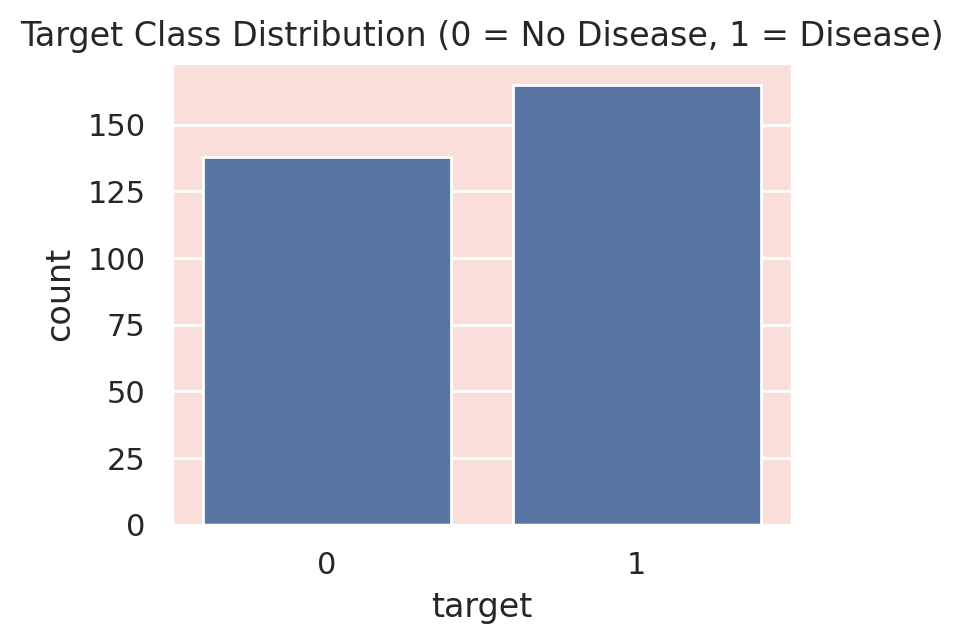

In [ ]:
#Target variable disrtibution
plt.figure(figsize=(4,3))
sns.countplot(x="target", data=df)
plt.title("Target Class Distribution (0 = No Disease, 1 = Disease)")
plt.show()

In [ ]:
continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"] #Selecting the continuous numerical columns
df[continuous_cols].describe() #Presenting the mean, standard deviation, min and max values and quartiles for the continuous variables

,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.623762,246.264026,149.646865,1.039604
std,9.082101,17.538143,51.830751,22.905161,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,47.500000,120.000000,211.000000,133.500000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000
75%,61.000000,140.000000,274.500000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


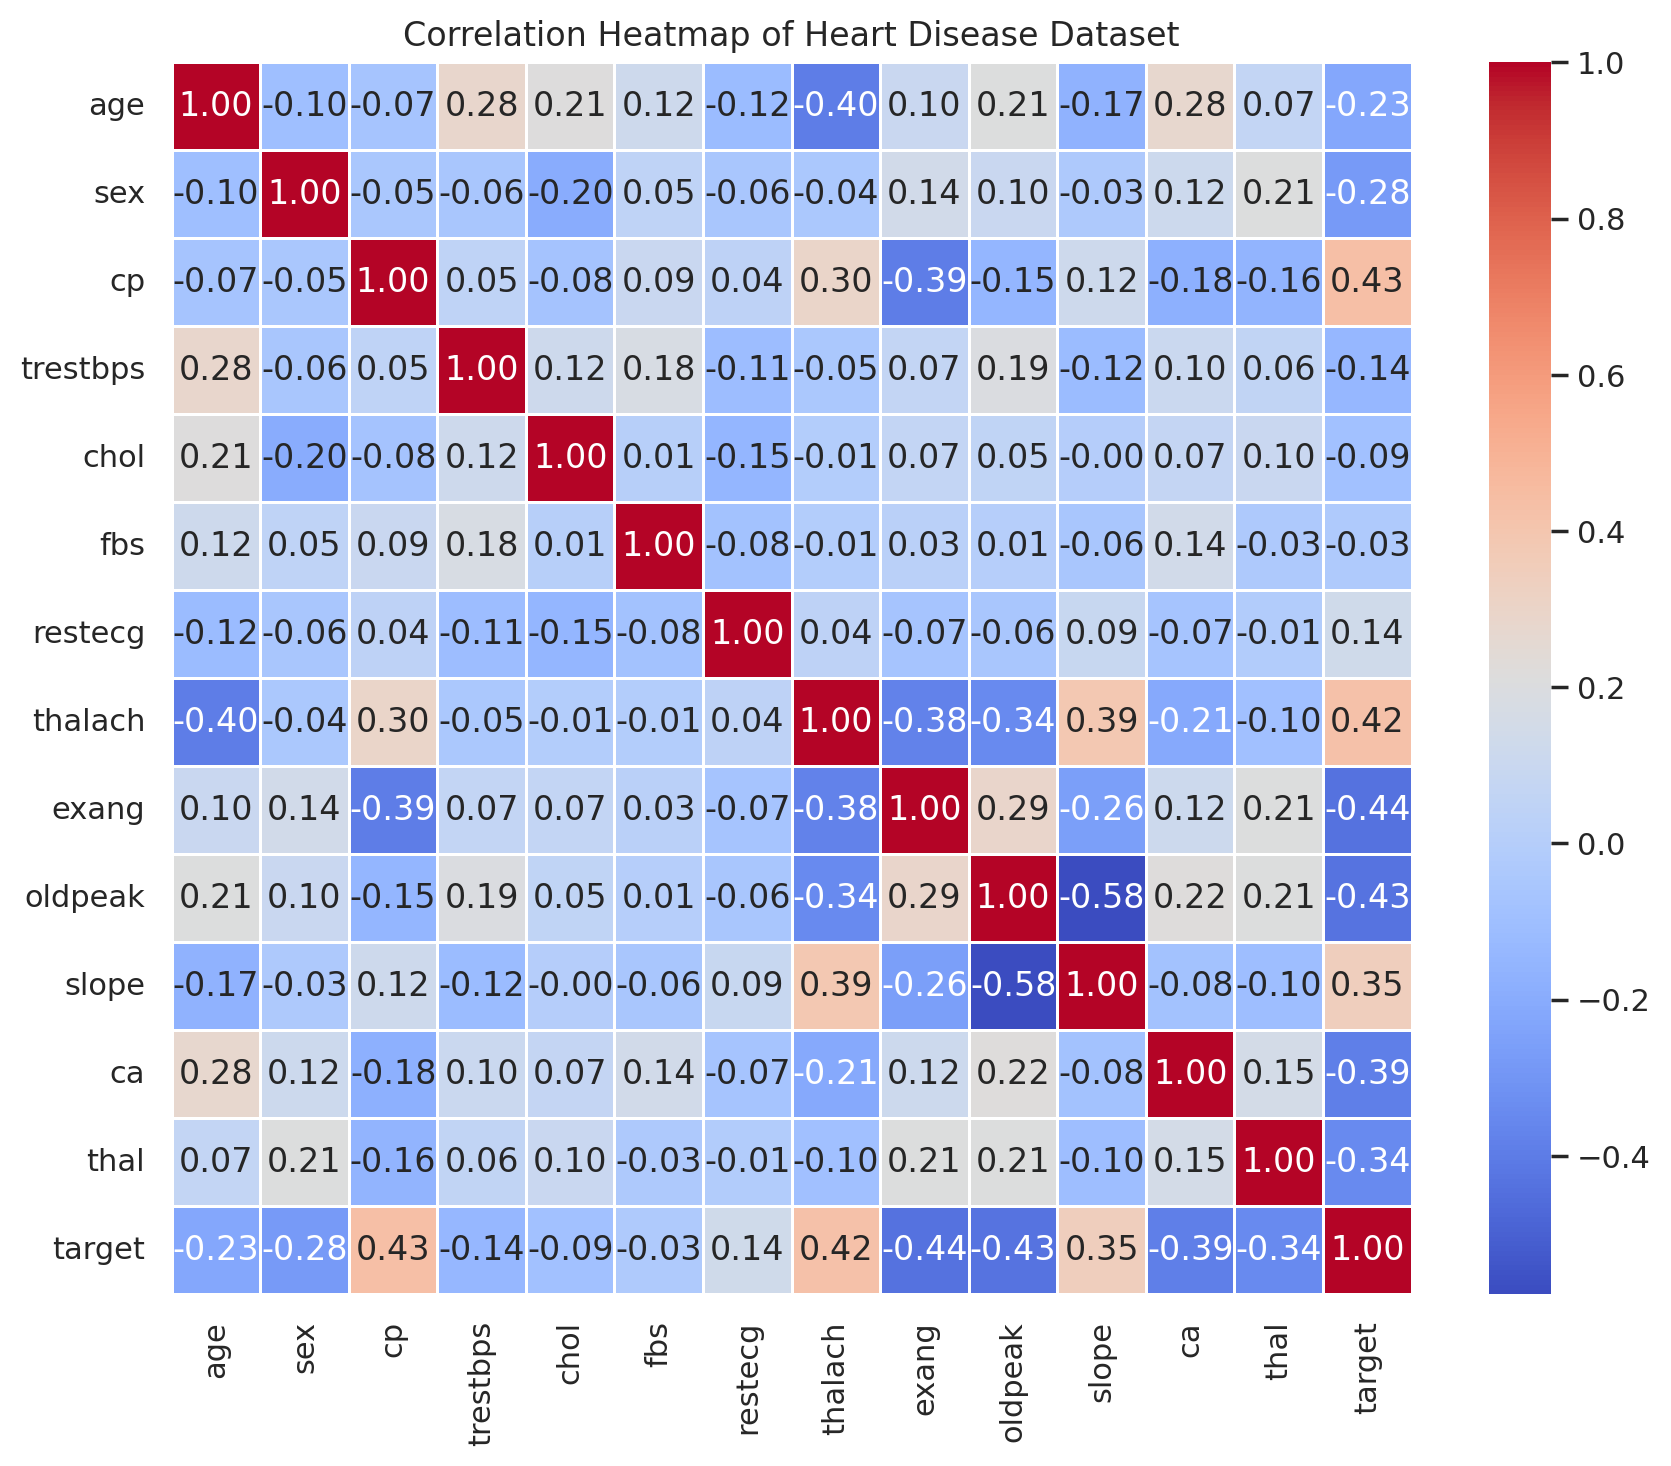

In [ ]:
#Correlation matrix
corr_matrix = df.corr()

#Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap of Heart Disease Dataset")
plt.show()

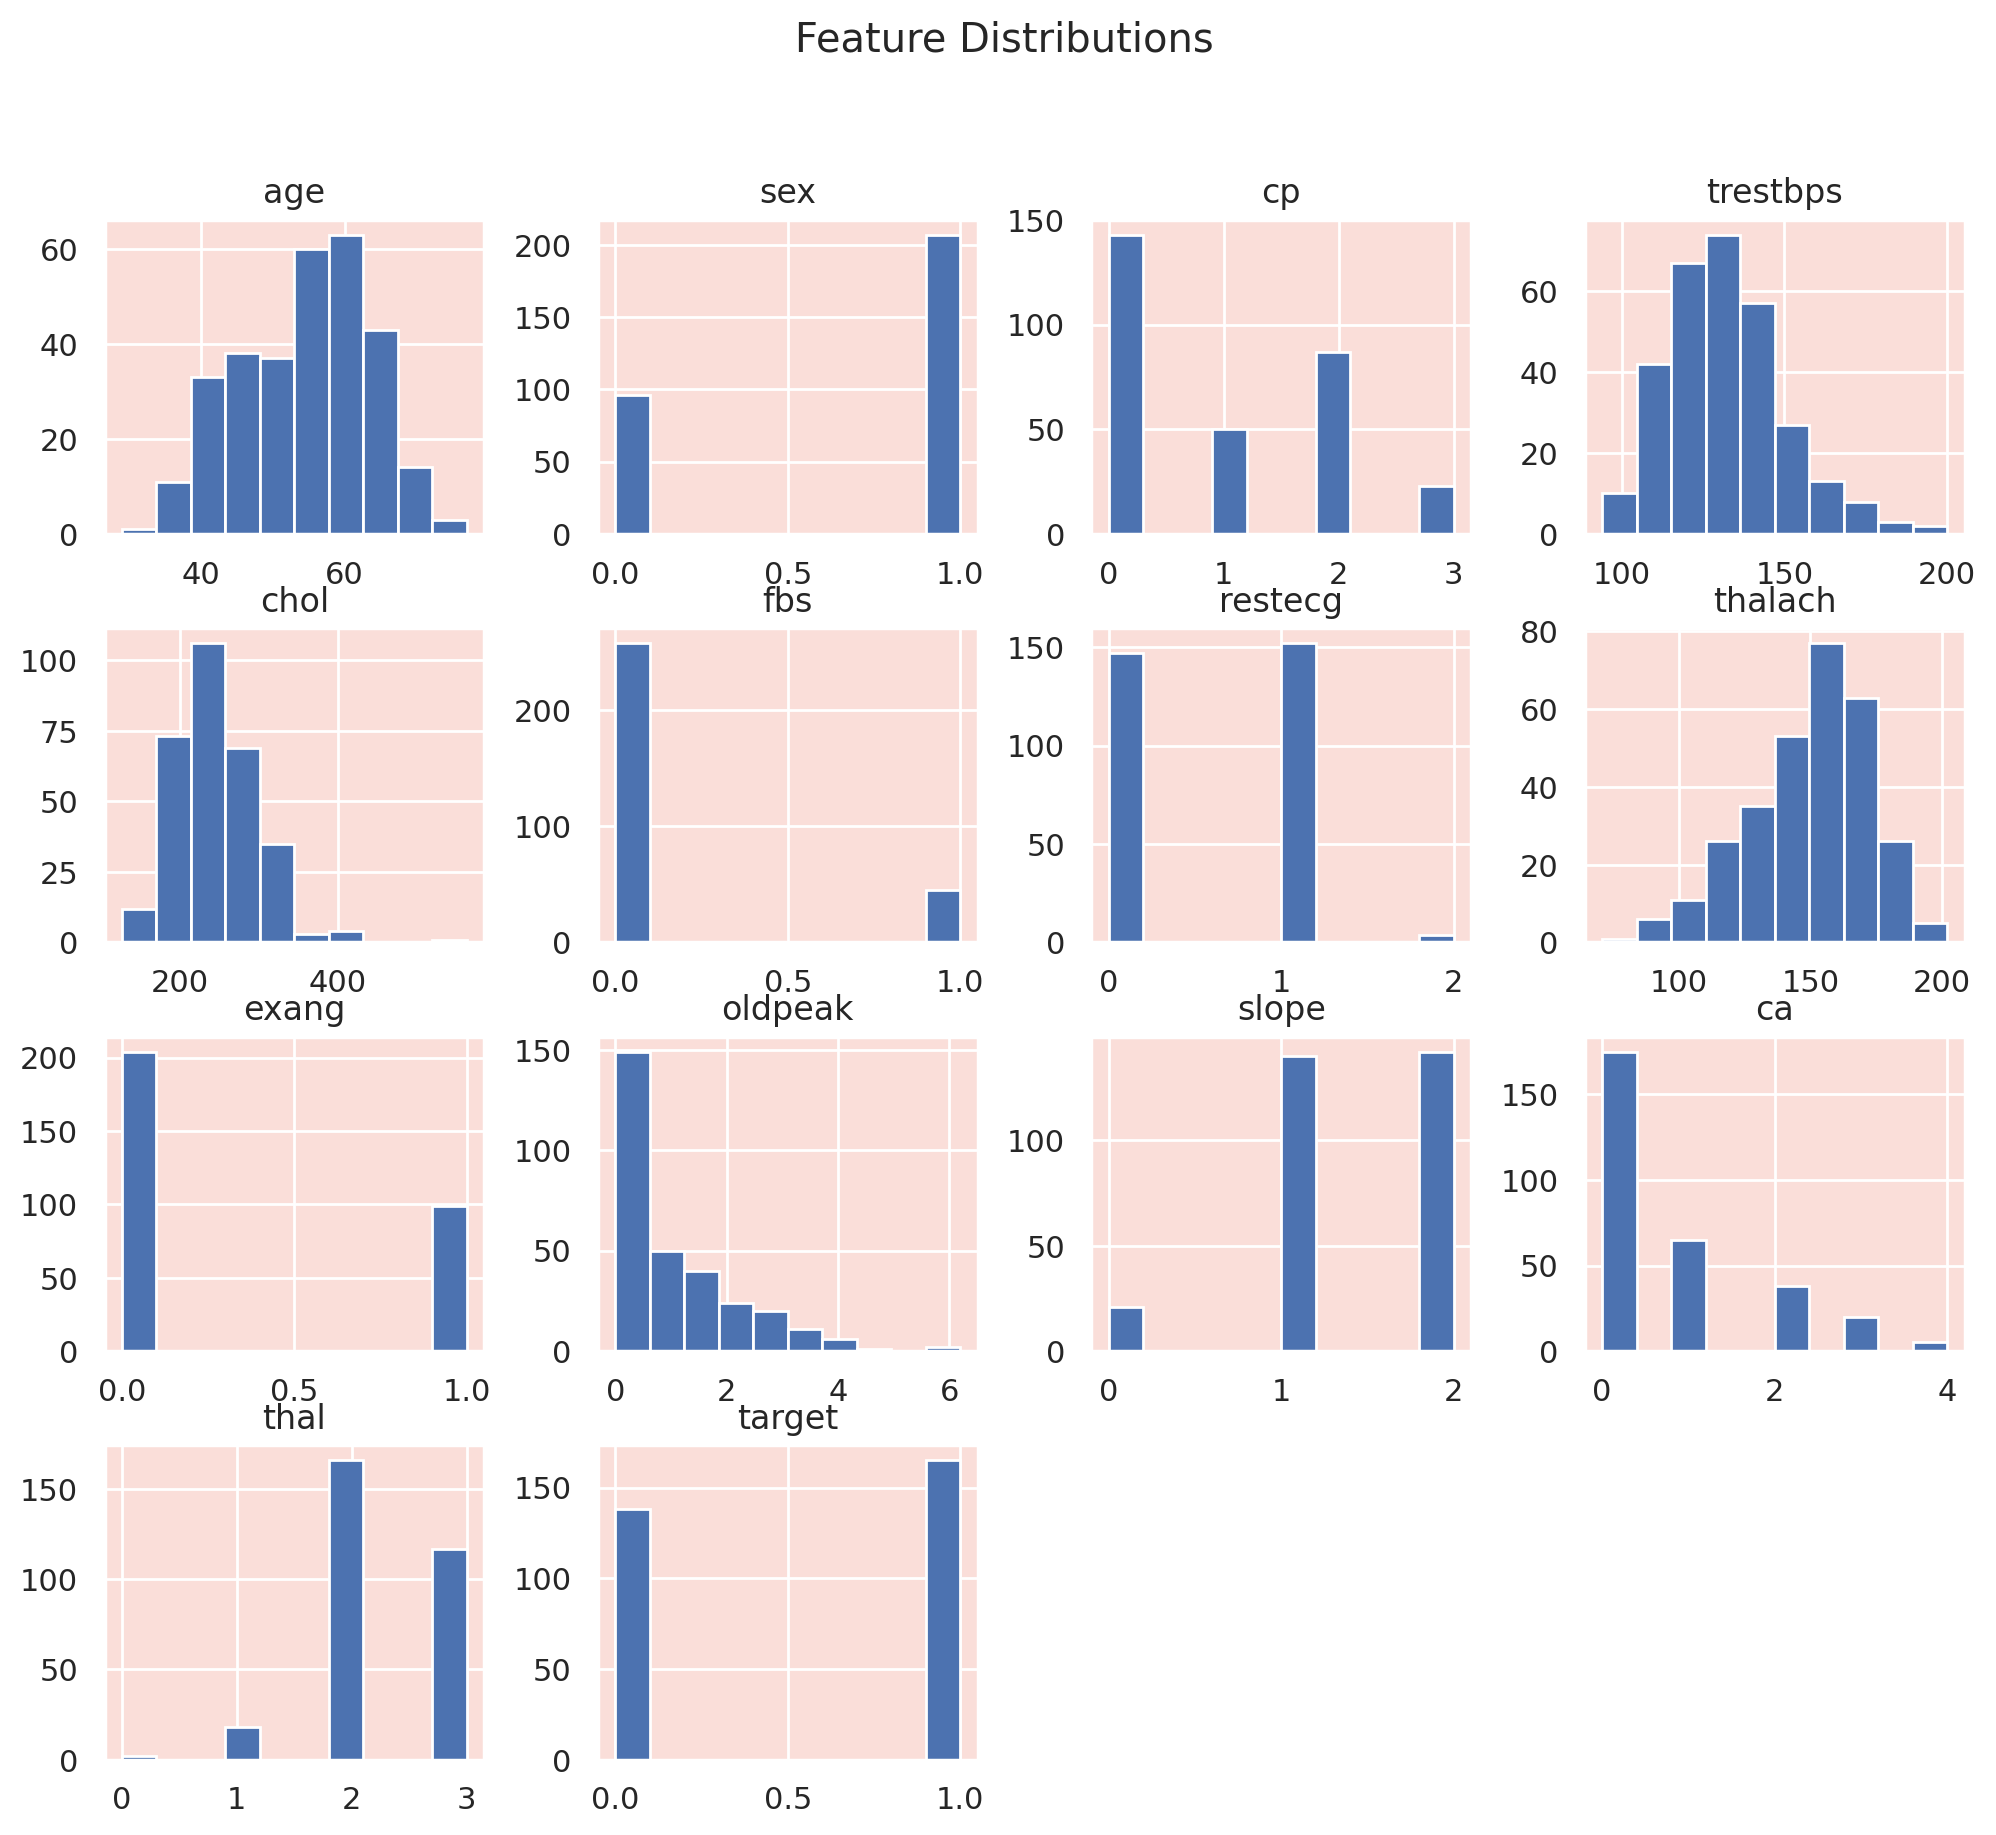

In [ ]:
#Feature distribution
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

## Classification models

In [ ]:
X = df.drop("target", axis=1) #X contains all feature variables (patient clinical measurements)
y = df["target"] #y contains the target label

In [ ]:
#Spliting data into 80% training set and 20% test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Defining five different classification models that I will be using
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

In [ ]:
results = [] #Empty list to store results

#Training and evaluating classical models
for name, model in models.items():
    if name in ["KNN", "Logistic Regression"]:
        model.fit(X_train_scaled, y_train) #Training KNN and Logistic Regression models
        y_pred = model.predict(X_test_scaled) #Generating predictions; KNN and Logistic Regression require scaled features
    else:
        model.fit(X_train, y_train) #Training Decision Tree, Random Forest and XGBoost models
        y_pred = model.predict(X_test) #Generating predictions; these models do not need scaling

    #Computing evaluation metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred), #Overall correctness
        "Precision": precision_score(y_test, y_pred), #How many predicted positives are correct
        "Recall": recall_score(y_test, y_pred), #How many actual positives were detected
        "F1-score": f1_score(y_test, y_pred) #Balance between precision and recall
    })

In [ ]:
results_df = pd.DataFrame(results)

#Sort by best F1-score
results_df = results_df.sort_values(by="F1-score", ascending=False)

#Comparing model performance
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-score
3        Random Forest  0.819672   0.761905  0.969697  0.853333
4              XGBoost  0.819672   0.775000  0.939394  0.849315
0                  KNN  0.803279   0.769231  0.909091  0.833333
1  Logistic Regression  0.803279   0.769231  0.909091  0.833333
2        Decision Tree  0.704918   0.702703  0.787879  0.742857


In [ ]:
#Best model - Random Forest
best_model = results_df.iloc[0]

print("\nBest Performing Model")
print(f"Model: {best_model['Model']}")
print(f"F1-score: {best_model['F1-score']:.3f}")


Best Performing Model
Model: Random Forest
F1-score: 0.853


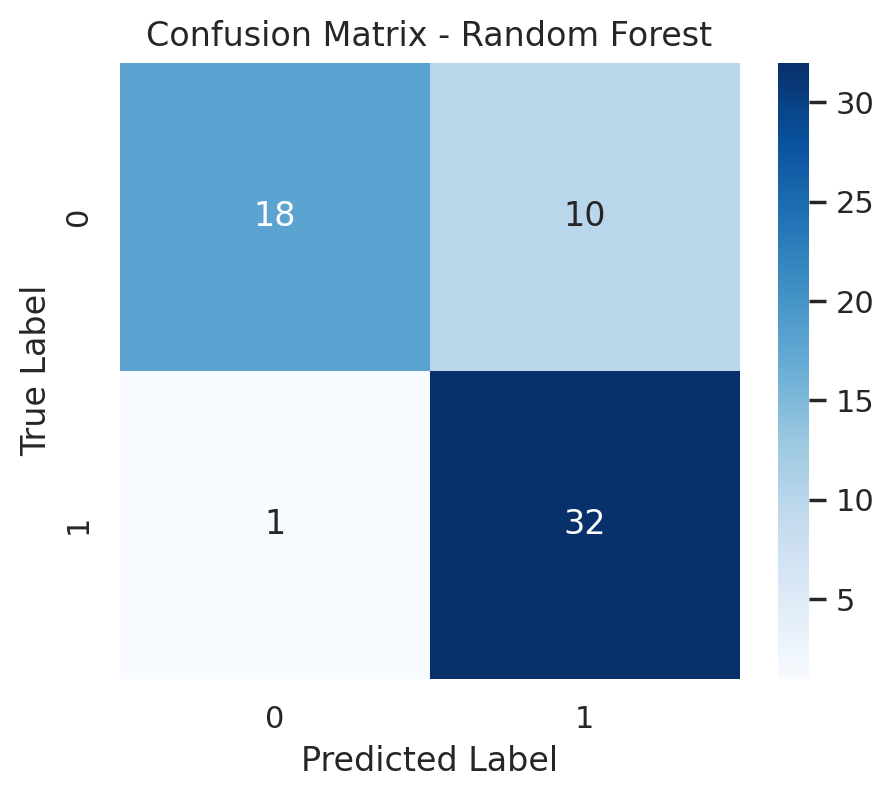

In [ ]:
#Confusion Matrix the best performing model - Random Forest

best_model = models["Random Forest"]
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

#We have 18 True Negatives (18 healthy patients were correctly classified as healthy), 10 False Postitives (10 healthy patients were incorrectly classified as having heart disease),
#1 False Negative (1 sick patient was incorrectly classified as healthy) and 32 True Positives (32 sick patients were correctly classified as sick)

## Neural Networks

In this section I would like to use Multilayer Perceptrons (MLPs) models:


1.   Basic MLP (single hidden layer)
2.   MLP with Dropout Regularization
1.   Deeper MLP

In [ ]:
#Defining the basic MLP
def build_basic_mlp():
    model = keras.Sequential([
        layers.Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)), #Input layer
        layers.Dense(1, activation='sigmoid') #Output layer
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
#Defining MLP with Dropout Regularization
def build_dropout_mlp():
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
#Defining the deeper MLP
def build_deep_mlp():
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
#The list of Neural Networks models I am using
nn_models = {
    "MLP Basic": build_basic_mlp(),
    "MLP Dropout": build_dropout_mlp(),
    "MLP Deep": build_deep_mlp()
}

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Training and evaluating the NN models
for name, model in nn_models.items():

    model.fit(
        X_train_scaled, y_train,
        epochs=50,
        batch_size=16,
        verbose=0,
        validation_split=0.2
    )

    y_pred_prob = model.predict(X_test_scaled)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


In [ ]:
results_df = pd.DataFrame(results)

#Only MLP models results
mlp_results = results_df[results_df["Model"].str.contains("MLP")]
mlp_results = mlp_results.sort_values(by="F1-score", ascending=False)

print(mlp_results)

         Model  Accuracy  Precision    Recall  F1-score
6  MLP Dropout  0.786885   0.763158  0.878788  0.816901
7     MLP Deep  0.770492   0.787879  0.787879  0.787879
5    MLP Basic  0.754098   0.750000  0.818182  0.782609


In [ ]:
#Best model out of NN models - MLP with Dropout Regularization
best_model_mlp = mlp_results.iloc[0]

print("\nBest Performing MLP Model")
print(f"Model: {best_model_mlp['Model']}")
print(f"F1-score: {best_model_mlp['F1-score']:.3f}")


Best Performing MLP Model
Model: MLP Dropout
F1-score: 0.817


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


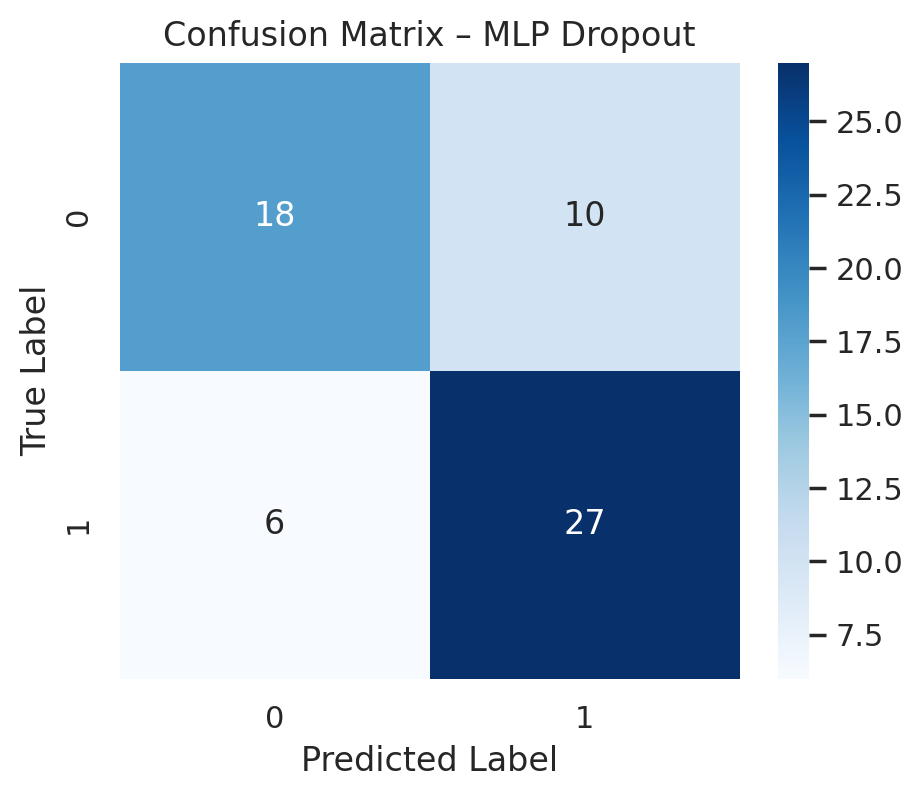

In [ ]:
#Confusion Matrix the best performing NN model - MLP with Dropout Regularization

mlp_dropout = build_dropout_mlp()

mlp_dropout.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=16,
    verbose=0,
    validation_split=0.2
)

#Predictions
y_pred_prob = mlp_dropout.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

#Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – MLP Dropout")

plt.show()

#We have 18 True Negatives (18 healthy patients were correctly classified as healthy), 10 False Postitives (10 healthy patients were incorrectly classified as having heart disease),
#5 False Negative (5 sick patients were incorrectly classified as healthy) and 28 True Positives (28 sick patients were correctly classified as sick)

## Ultimate comparison

MLP Dropout was the best-performing neural network. However, Random Forest achieved the best overall performance.

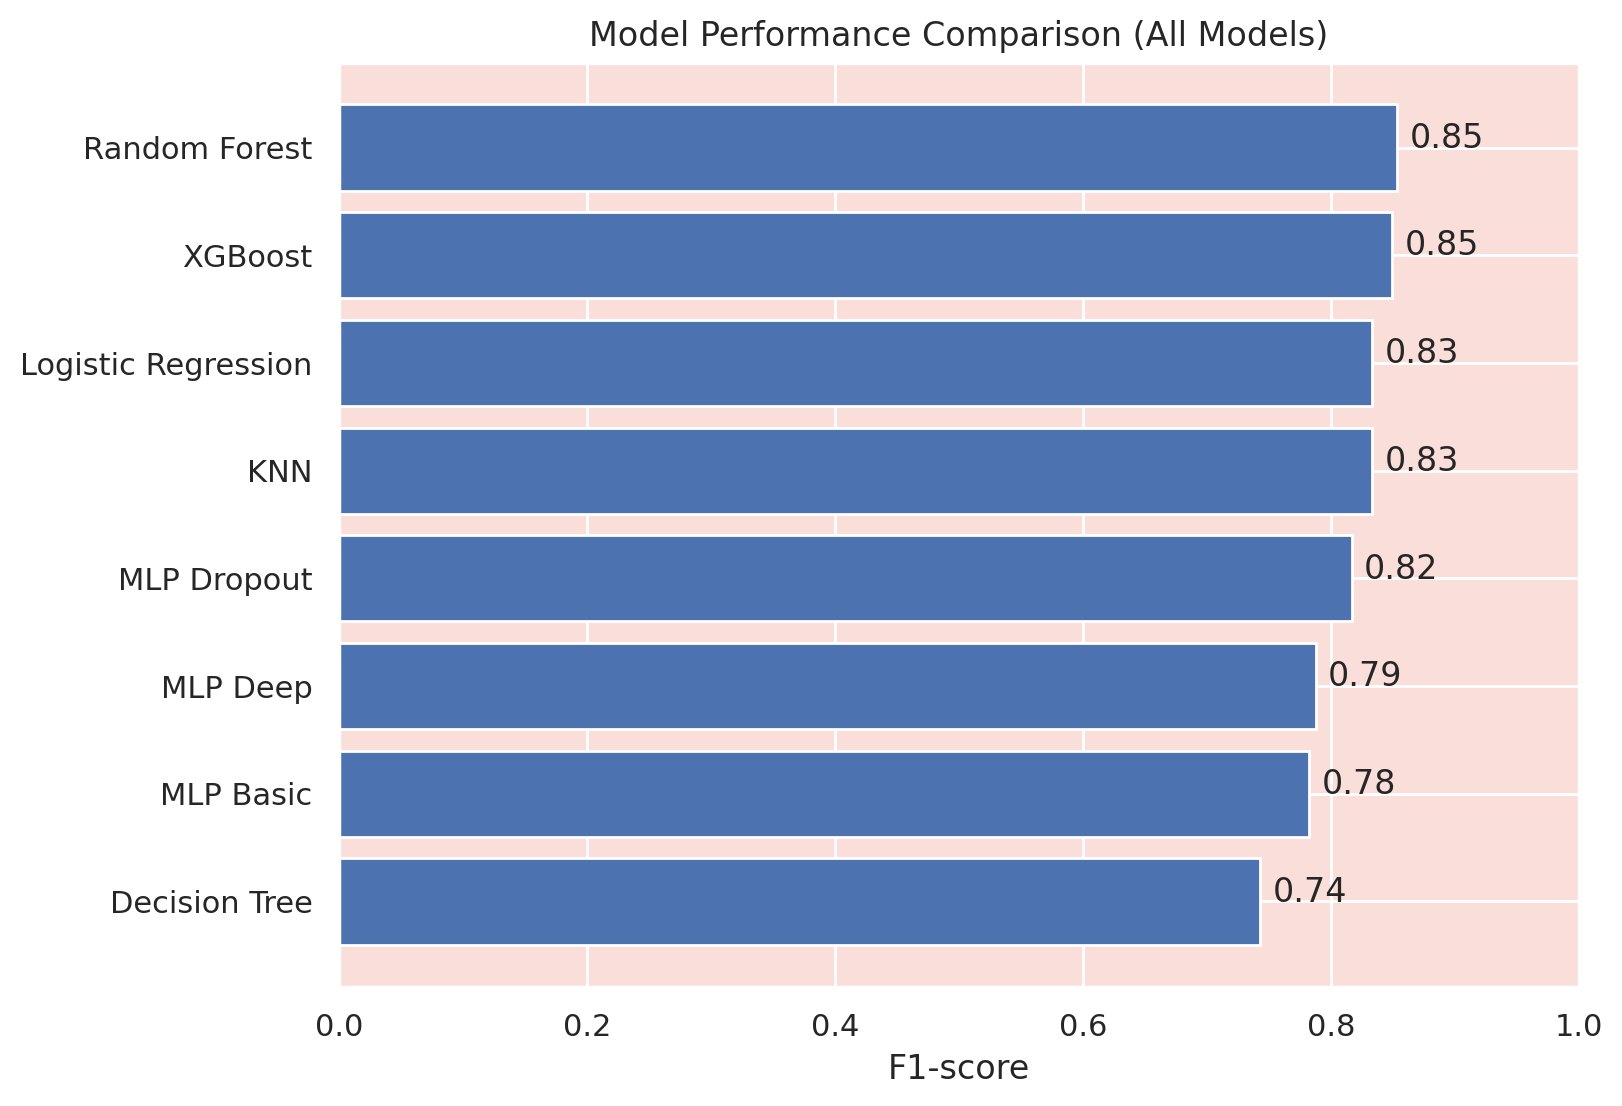

In [ ]:
results_df = pd.DataFrame(results)

#Sort by F1-score
results_df = results_df.sort_values(by="F1-score", ascending=True)

#Plotting the horizontal bar chart
plt.figure(figsize=(8,6))
plt.barh(results_df["Model"], results_df["F1-score"])

plt.xlabel("F1-score")
plt.title("Model Performance Comparison (All Models)")
plt.xlim(0,1)

#Add value labels
for index, value in enumerate(results_df["F1-score"]):
    plt.text(value + 0.01, index, f"{value:.2f}")

plt.show()